In [5]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.optimize import curve_fit
from scipy import integrate
from pathlib import Path
import os
import glob
import constantes as c
import uncertainties.unumpy as unp
from uncertainties import ufloat

class Señal:
    def __init__(self, file):
        self.tV, self.V, self.tI, self.I = self.csv(file)

    def csv(self, file):
        df = pd.read_csv(Path(file).expanduser(), index_col=0)
        t_volt, volt = [np.asarray(df[f'Tiempo CH{c.CH_VOLT}']), 
                        np.asarray(df[f'Voltaje CH{c.CH_VOLT}'])]
        t_istr, istr = [np.asarray(df[f'Tiempo CH{c.CH_ISTR}']), 
                1/c.R * np.asarray(df[f'Voltaje CH{c.CH_ISTR}'])]
        return t_volt, volt, t_istr, istr


class SeñalReff(Señal):
    def __init__(self, file):
        super().__init__(file)
        self.Vpp, self.Vpp_err, self.T, self.T_err = self.fit_sin()

    def fit_sin(self):
        def sin(x, A, T, p, B): return A*np.sin(2*np.pi/T*x + p) + B
        initialGuess = [7500, 1/8000, 0, 10000]
        popt, pcov = curve_fit(sin, self.tV, self.V, p0=initialGuess)
        perr = np.sqrt(np.diag(pcov))
        A, T, p, B = popt
        A_err, T_err, p_err, B_err = perr
        return 2*A, 2*A_err, T, T_err
        

class SeñalZoom(Señal):
    def __init__(self, file_zoom, T):
        super().__init__(file_zoom)
        #self.t, self.I, self.V = self.filtro()
        self.I = self.fit_sin(T)
        self.P_avg = self.potencia(T)
        self.I_avg = self.corriente()

    def filtro(self):
        dt = 50
        # 0.005 np.max(self.I)/2
        indices =  np.where(self.I > 0.005)[0]
        #indices =  np.where(self.I/np.max(self.I) > 0.4)[0]
        i, f = indices[0] - dt, indices[-1] + dt
        t_filtro, y = np.linspace([self.tI[i], np.mean(self.I[i-dt:i])], [self.tI[f], np.mean(self.I[f:f+dt])], f-i).T
        I_filtro = self.I[i:f] - y
        V_filtro = self.V[i:f]
        return t_filtro, I_filtro, V_filtro
    
    def fit_sin(self, T):
        def sin(x, A, p, B): return A*np.sin(2*np.pi/T*x + p) + B
        initialGuess = [7500, 0, 10000]
        popt, pcov = curve_fit(sin, self.tI, self.I, p0=initialGuess)
        perr = np.sqrt(np.diag(pcov))
        A, p, B = popt
        I = self.I - sin(self.tI, A, p, B)
        plt.plot(self.tI, I)
        return I

    def potencia(self, T):
        return integrate.simpson(self.I * self.V, x=self.tI) / T
    
    def corriente(self):
        return np.mean(self.I)



class SeñalProm:
    def __init__(self, folder):
        self.señalesReff, self.señalesZoom = self.data(folder)
        self.P_avg = self.potencia()
        self.V_vpp = self.voltaje()
        self.I_avg = self.corriente()

    def data(self, folder):
        files = glob.glob(os.path.join(c.ROOT, folder, '*.csv'))
        señalesReff = [SeñalReff(file) for file in files if 'reff' in os.path.basename(file)]
        señalesZoom = [SeñalZoom(file, señalesReff[0].T) for file in files if 'reff' not in os.path.basename(file)]
        return señalesReff, señalesZoom
    
    def potencia(self):
        P_avg = np.mean([señal.P_avg for señal in self.señalesZoom], axis=0)
        P_std = np.std([señal.P_avg for señal in self.señalesZoom], axis=0)
        return unp.uarray(P_avg, P_std)

    def voltaje(self):
        V_vpp = np.mean([señal.Vpp for señal in self.señalesReff], axis=0)
        V_std = np.mean([señal.Vpp_err for señal in self.señalesReff], axis=0)
        return unp.uarray(V_vpp, V_std)
    
    def corriente(self):
        I_avg = np.mean([señal.I_avg for señal in self.señalesZoom], axis=0)
        I_std = np.std([señal.I_avg for señal in self.señalesZoom], axis=0) # Dudas, ¿asi se calculaba el error del promedio de un promedio? Además, estamos con std de numpy que está sesgado
        return unp.uarray(I_avg, I_std)
    
    def __repr__(self):
        return f'''
                    I = {self.I_avg * 1000} mA
                    V = {self.V_vpp / 1000} kV
                    P = {self.P_avg} W'''



                    I = (1.5+/-1.9)e-09 mA
                    V = 11.478+/-0.007 kV
                    P = -0.005+/-0.011 W

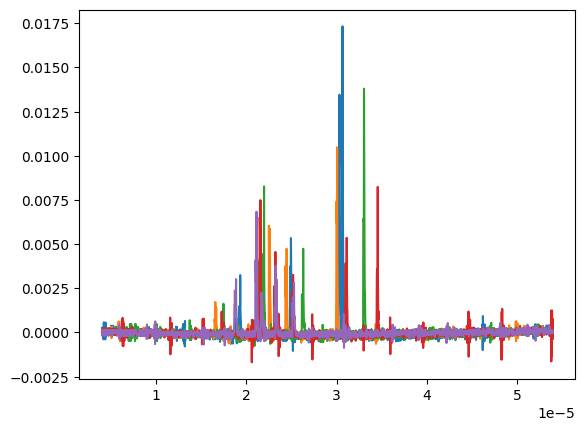

In [6]:
SeñalProm('28-05/vidrio/12.0')

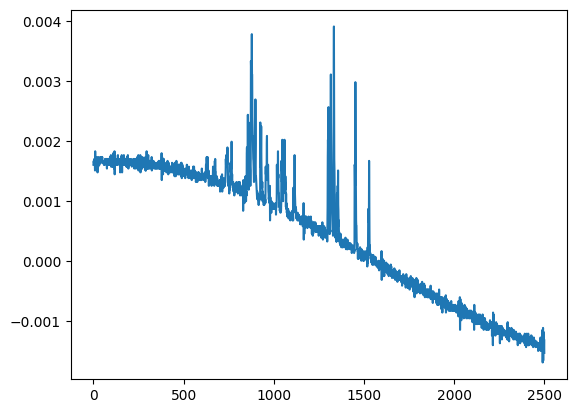

In [8]:
folder = '28-05/vidrio/12.0'
files = glob.glob(os.path.join(c.ROOT, folder, '*.csv'))
señalesReff = [SeñalReff(file) for file in files if 'reff' in os.path.basename(file)]
señales_I = [Señal(file).I for file in files if 'reff' not in os.path.basename(file)]
plt.plot(np.mean(señales_I, axis=0))
